# Lab02

Height: 916
Width: 1374


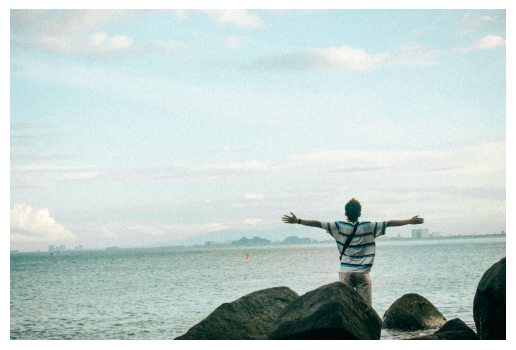

In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
img_original = cv2.imread("ava.png")
h, w = img_original.shape[:2]
print("Height:", h)
print("Width:", w)

img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
plt.imshow(img_original)
plt.axis("off")
plt.show()

## 1. Argorithm: Tăng giảm mức xám 

```
Input: Ảnh I, số c
Output: Ảnh mới
Thực hiện: Với mọi x, y: I(x, y) = I(x, y) + c
```

In [6]:
# I: ảnh xám đầu vào
# c: giá trị mức xám thay đổi
def tangGiamMucXam(I, c, MIN, MAX):
    I_result = np.copy(I)
    for i in range(I.shape[0]):
        for j in range(I.shape[1]):
            p = int(I[i, j]) + c
            if p > MAX: 
                I_result[i, j] = MAX
            elif p < MIN:
                I_result[i, j] = MIN
            else: 
                I_result[i, j] = p
    return I_result
            

Ví dụ: 

In [7]:
I = np.array(
    [
        [1, 2, 4, 6, 7],
        [2, 1, 3, 4, 5], 
        [7, 2, 6, 9, 1],
        [4, 1, 2, 1, 2]
    ], dtype = np.uint8
)

print("Base:")
print(I)

print("Result:")
print(tangGiamMucXam(I, -5, 0, 255))

Base:
[[1 2 4 6 7]
 [2 1 3 4 5]
 [7 2 6 9 1]
 [4 1 2 1 2]]
Result:
[[0 0 0 1 2]
 [0 0 0 0 0]
 [2 0 1 4 0]
 [0 0 0 0 0]]


### 1.1 Read Grayscale 

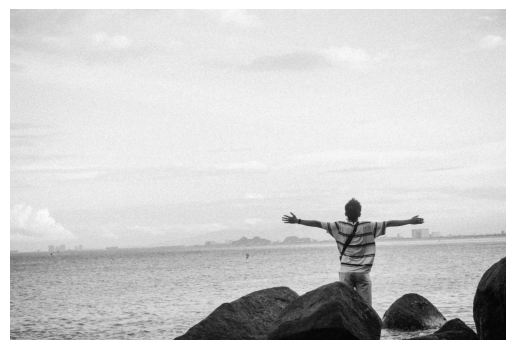

In [8]:
img = img_original.copy()
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(img_gray, cmap = "gray")
plt.axis("off")
plt.show()

### 1.2 Change Grayscale

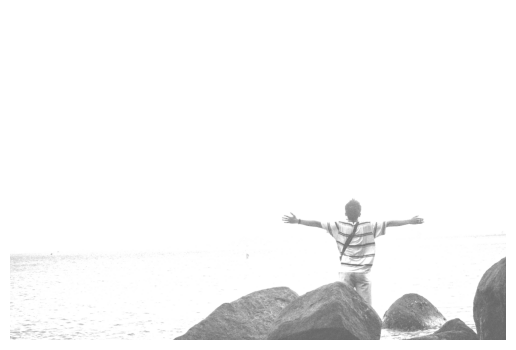

In [9]:
img = img_gray.copy()
c = 100 

img = tangGiamMucXam(img, c, 0, 255)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

## 2. Practice: Use Algorithm with picture (r,g,b)

Height: 916
Width: 1374
Channels: 3


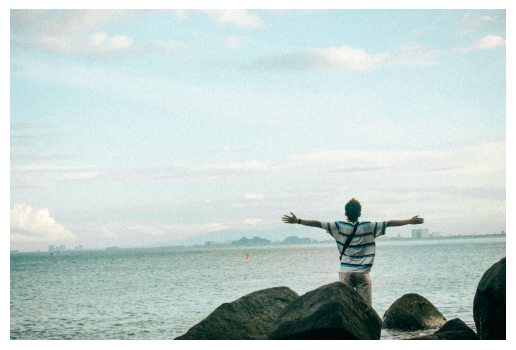

In [10]:
img = cv2.imread("ava.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w, c = img.shape

print("Height:", h)
print("Width:", w)
print("Channels:", c)

plt.imshow(img)
plt.axis("off")
plt.show()


- Hàm tách ảnh màu thành 3 ảnh xám: cv2.split
- Hàm ghép 3 ảnh xám thành ảnh màu: cv2.merge

In [11]:
def split(img, cr=1, cg=1, cb=1):
    b, g , r = cv2.split(img)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(b, cmap="gray")
    plt.title("Kênh B - trước")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(g, cmap="gray")
    plt.title("Kênh G - trước")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(r, cmap="gray")
    plt.title("Kênh R - trước")
    plt.axis("off")

    plt.show()

    b = tangGiamMucXam(b, cb, 0, 255)
    g = tangGiamMucXam(g, cg, 0, 255)
    r = tangGiamMucXam(r, cr, 0, 255)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(b, cmap="gray")
    plt.title(f"Kênh B - sau ({cb})")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(g, cmap="gray")
    plt.title(f"Kênh G - sau ({cg})")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(r, cmap="gray")
    plt.title(f"Kênh R - sau ({cr})")
    plt.axis("off")

    plt.show()

    return b, g, r

    

    

In [12]:
def mergeVaShow(b, g, r):
    # Ghép 3 kênh lại thành ảnh màu
    img = cv2.merge([b, g, r])

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.title("Ảnh sau khi merge")
    plt.axis("off")
    plt.show()

    return img

a. Ảnh kết quả sẽ thế nào nếu

*   c_r = 70
*   c_g = -70
*   c_b = -70

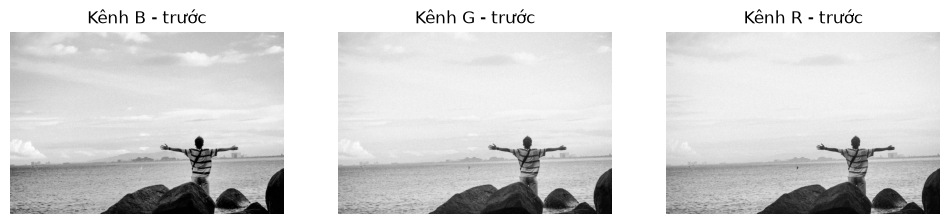

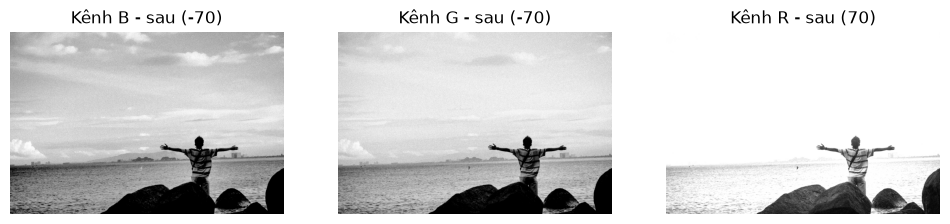

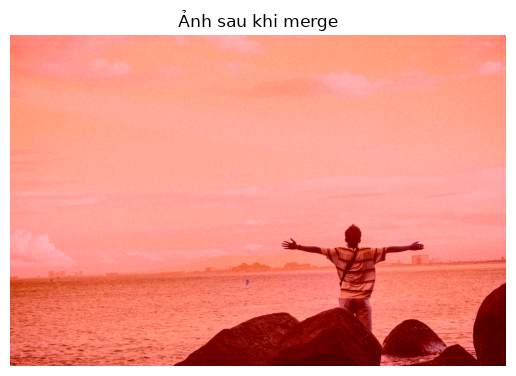

In [13]:
b, g, r = split(
    img,
    cr=70,
    cg=-70,
    cb=-70
)

img_result = mergeVaShow(b, g, r)

b. Ảnh kết quả sẽ thế nào nếu

*   c_r = -70
*   c_g = 70
*   c_b = -70

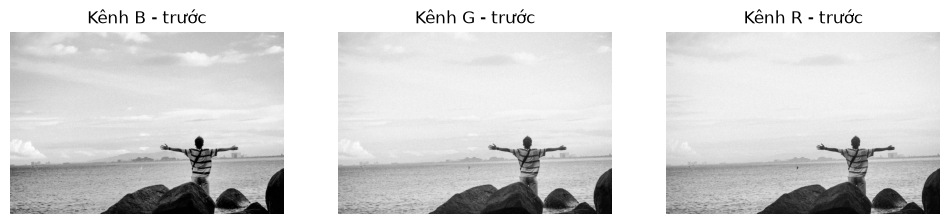

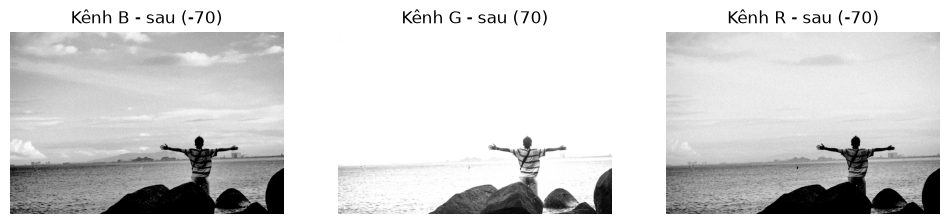

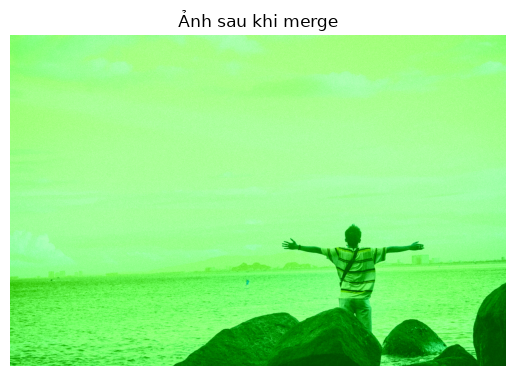

In [14]:
b, g, r = split(
    img,
    cr=-70,
    cg=70,
    cb=-70
)

img_result = mergeVaShow(b, g, r)

Full:

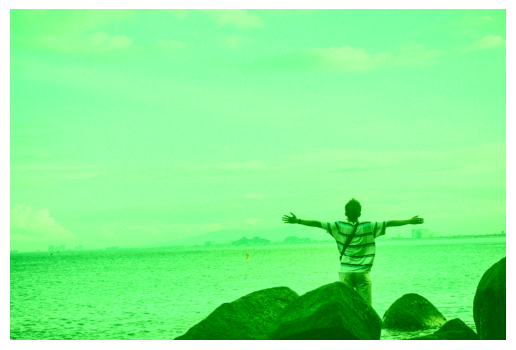

In [15]:
ex3 = img.copy()

cR = -70
cG = 70
cB = -70

for i in range(h):
    for j in range(w):
        value = int(img[i, j, 0]) + cR
        if value > 255:
            value = 255
        elif value < 0:
            value = 0
        ex3[i, j, 0] = value
        
        value = int(img[i, j, 1]) + cG
        if value > 255:
            value = 255
        elif value < 0:
            value = 0
        ex3[i, j, 1] = value
        
        value = int(img[i, j, 2]) + cB
        if value > 255:
            value = 255
        elif value < 0:
            value = 0
        ex3[i, j, 2] = value


plt.imshow(ex3)
plt.axis("off")
plt.show()

**Câu 2:** Thay vì thay đổi đều cả ảnh đầu vào với 1 giá trị c cố định.

a. Ảnh kết quả sẽ thế nào nếu ta thay đổi như sau:
```
Với mọi x, y: c = x mod 256, thực hiện tăng giảm mức xám với c
```

b. Ảnh kết quả sẽ thế nào nếu ta thay đổi như sau:
```
Với mọi x, y: c = (x+y) mod 256, thực hiện tăng giảm mức xám với c
```

c. Ảnh kết quả sẽ thế nào nếu ta thay đổi như sau:
```
Với mọi x, y: c = ((chiều rộng - x + y) mod 256)-255, thực hiện tăng giảm mức xám với c
```

*mod là ký hiệu phép chia lấy phần dư*

Thực hành để kiểm tra kết quả.

In [16]:
def thayDoiTheoCongThuc(I, congThuc):
    I_result = np.copy(I)

    height, width = I.shape[:2]

    for y in range(height):
        for x in range(width):
            c = congThuc(x, y, width, height)

            p = int(I[y, x]) + c

            if p > 255:
                I_result[y, x] = 255
            elif p < 0:
                I_result[y, x] = 0
            else:
                I_result[y, x] = p

    return I_result

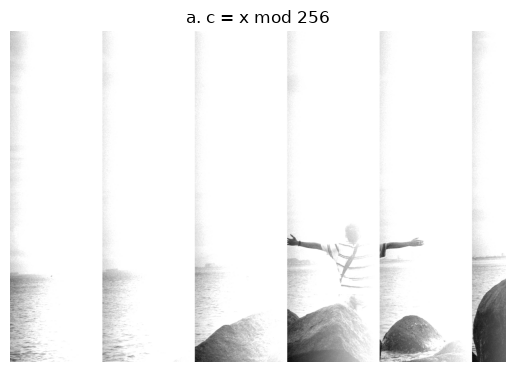

In [17]:
I_a = thayDoiTheoCongThuc(
    img_gray,
    lambda x, y, width, height: x % 256
)

plt.imshow(I_a, cmap="gray")
plt.title("a. c = x mod 256")
plt.axis("off")
plt.show()

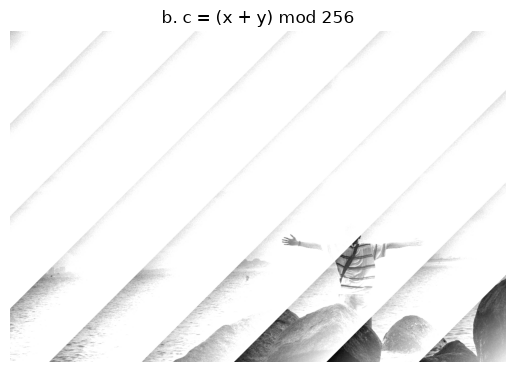

In [18]:
I_b = thayDoiTheoCongThuc(
    img_gray,
    lambda x, y, width, height: (x + y) % 256
)

plt.imshow(I_b, cmap="gray")
plt.title("b. c = (x + y) mod 256")
plt.axis("off")
plt.show()

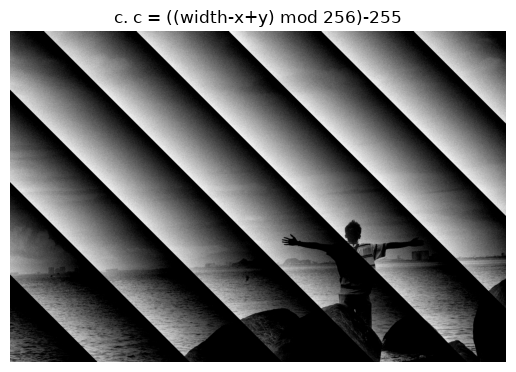

In [19]:
I_c = thayDoiTheoCongThuc(
    img_gray,
    lambda x, y, width, height: ((width - x + y) % 256) - 255
)

plt.imshow(I_c, cmap="gray")
plt.title("c. c = ((width-x+y) mod 256)-255")
plt.axis("off")
plt.show()

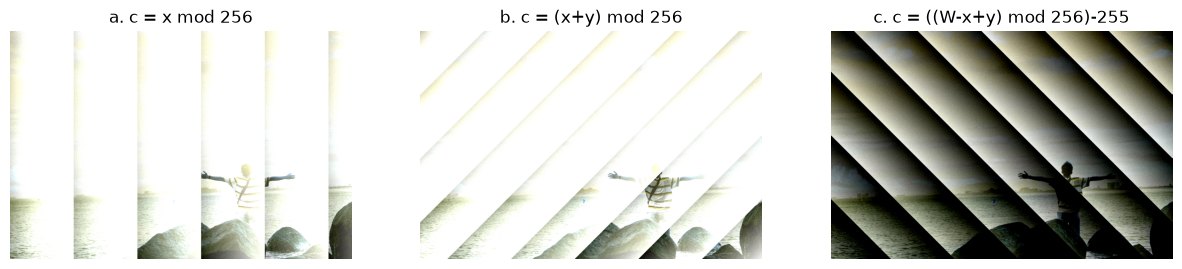

In [20]:
def thayDoiRGB(I, congThuc):
    I_result = np.copy(I)

    height, width = I.shape[:2]

    for y in range(height):
        for x in range(width):
            c = congThuc(x, y, width, height)

            # Thay đổi cả 3 kênh B, G, R
            for k in range(3):
                p = int(I[y, x, k]) + c

                if p > 255:
                    I_result[y, x, k] = 255
                elif p < 0:
                    I_result[y, x, k] = 0
                else:
                    I_result[y, x, k] = p

    return I_result

I_a = thayDoiRGB(
    img,
    lambda x, y, width, height: x % 256
)

I_b = thayDoiRGB(
    img,
    lambda x, y, width, height: (x + y) % 256
)


I_c = thayDoiRGB(
    img,
    lambda x, y, width, height: ((width - x + y) % 256) - 255
)


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(I_a, cv2.COLOR_BGR2RGB))
plt.title("a. c = x mod 256")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(I_b, cv2.COLOR_BGR2RGB))
plt.title("b. c = (x+y) mod 256")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(I_c, cv2.COLOR_BGR2RGB))
plt.title("c. c = ((W-x+y) mod 256)-255")
plt.axis("off")

plt.show()

## 3. Phân ngưỡng


### 3.1 Argorithm

```
Input: Ảnh I, ngưỡng T, MIN, MAX
Output: Ảnh mới
Thực hiện:
    Với mọi x, y:
        if I(x, y) > T: I(x, y) = MAX
        else: I(x, y) = MIN

Hoặc có thể mô tả như sau: I(x, y) = (I(x, y)>T) ? MAX : MIN
```

In [21]:
# I: ảnh xám đầu vào
# T: ngưỡng
# MIN, MAX: 2 cận
def phanNguong(I, T, MIN, MAX):
    for i in range(I.shape[0]):
        for j in range(I.shape[1]):
            I[i, j] = MAX if I[i, j] > T else MIN

In [22]:
I = np.array([
    [1, 2, 4, 6, 7],
    [2, 1, 3, 4, 5],
    [7, 2, 6, 9, 1],
    [4, 1, 2, 1, 2]
], dtype=np.uint8)
print("anh ban dau:")
print(I)

# phân ngưỡng với T=4, MIN=0, MAX=9
phanNguong(I, 4, 0, 9)
print("anh ket qua:")
print(I)

anh ban dau:
[[1 2 4 6 7]
 [2 1 3 4 5]
 [7 2 6 9 1]
 [4 1 2 1 2]]
anh ket qua:
[[0 0 0 9 9]
 [0 0 0 0 9]
 [9 0 9 9 0]
 [0 0 0 0 0]]


In [23]:
# I: ảnh xám đầu vào
# T: ngưỡng
# MIN, MAX: 2 cận
def phanNguong(I, T, MIN, MAX):
    I_kq = np.copy(I)
    for i in range(I.shape[0]):
        for j in range(I.shape[1]):
            I_kq[i, j] = MAX if I[i, j] > T else MIN
    return I_kq

In [24]:
I = np.array([
    [1, 2, 4, 6, 7],
    [2, 1, 3, 4, 5],
    [7, 2, 6, 9, 1],
    [4, 1, 2, 1, 2]
], dtype=np.uint8)

I_kq1 = phanNguong(I, 4, 0, 9) # phân ngưỡng với T=4, MIN=0, MAX=9
I_kq2 = phanNguong(I, 8, 0, 1) # phân ngưỡng với T=8, MIN=0, MAX=1

print("anh ban dau:")
print(I)
print("anh ket qua 1:")
print(I_kq1)
print("anh ket qua 2:")
print(I_kq2)

anh ban dau:
[[1 2 4 6 7]
 [2 1 3 4 5]
 [7 2 6 9 1]
 [4 1 2 1 2]]
anh ket qua 1:
[[0 0 0 9 9]
 [0 0 0 0 9]
 [9 0 9 9 0]
 [0 0 0 0 0]]
anh ket qua 2:
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 1 0]
 [0 0 0 0 0]]


**Bản chất của thuật toán phân ngưỡng nằm ở việc quyết định giá trị điểm ảnh mới dựa trên việc so sánh với ngưỡng.**

Ví dụ phân ngưỡng có thể có các biến thể như sau:
```
a. I(x, y) = (I(x, y)>T) ? MIN : MAX
b. I(x, y) = (I(x, y)>T) ? MAX : I(x, y)
c. I(x, y) = (I(x, y)<T) ? MIN : I(x, y)
...
```

In [25]:
hamqd_0 = lambda p, T, MIN, MAX: MAX if p > T else MIN
# I: ảnh xám đầu vào
# T: ngưỡng
# MIN, MAX: 2 cận
# hamqd: hàm quyết định giá trị điểm ảnh mới
def phanNguong(I, T, MIN, MAX, hamqd=hamqd_0):
    I_kq = np.copy(I)
    for i in range(I.shape[0]):
        for j in range(I.shape[1]):
            I_kq[i, j] = hamqd(I[i, j], T, MIN, MAX)
    return I_kq

In [26]:
I_kq1 = phanNguong(I, 4, 0, 9) # phân ngưỡng với T=4, MIN=0, MAX=9
I_kq2 = phanNguong(I, 8, 0, 1) # phân ngưỡng với T=8, MIN=0, MAX=1

print("anh ban dau:")
print(I)
print("anh ket qua 1:")
print(I_kq1)
print("anh ket qua 2:")
print(I_kq2)

anh ban dau:
[[1 2 4 6 7]
 [2 1 3 4 5]
 [7 2 6 9 1]
 [4 1 2 1 2]]
anh ket qua 1:
[[0 0 0 9 9]
 [0 0 0 0 9]
 [9 0 9 9 0]
 [0 0 0 0 0]]
anh ket qua 2:
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 1 0]
 [0 0 0 0 0]]


In [27]:
hamqd_a = lambda p, T, MIN, MAX: MIN if p > T else MAX
hamqd_b = lambda p, T, MIN, MAX: MAX if p > T else p
hamqd_c = lambda p, T, MIN, MAX: MIN if p < T else p

In [28]:
I_kqa = phanNguong(I, 4, 0, 9, hamqd_a)
I_kqb = phanNguong(I, 4, 0, 9, hamqd_b)
I_kqc = phanNguong(I, 4, 0, 9, hamqd_c)

print("anh ket qua a:")
print(I_kqa)
print("anh ket qua b:")
print(I_kqb)
print("anh ket qua c:")
print(I_kqc)

anh ket qua a:
[[9 9 9 0 0]
 [9 9 9 9 0]
 [0 9 0 0 9]
 [9 9 9 9 9]]
anh ket qua b:
[[1 2 4 9 9]
 [2 1 3 4 9]
 [9 2 9 9 1]
 [4 1 2 1 2]]
anh ket qua c:
[[0 0 4 6 7]
 [0 0 0 4 5]
 [7 0 6 9 0]
 [4 0 0 0 0]]


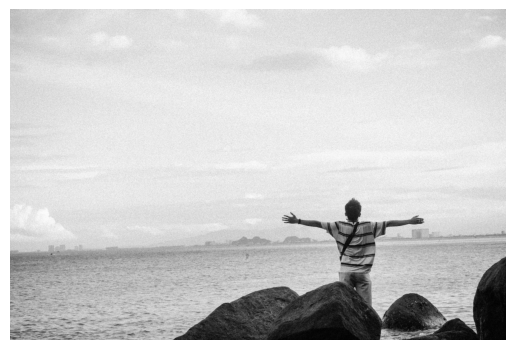

In [29]:
i1 = cv2.imread("ava.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(i1, cmap="gray")
plt.axis("off")
plt.show()

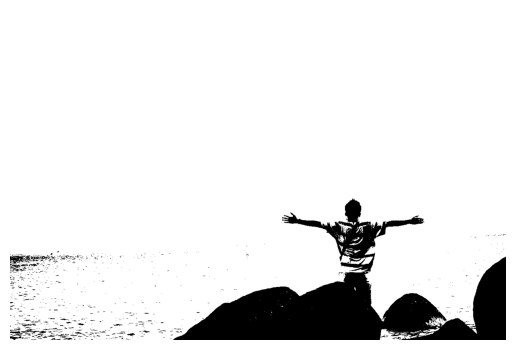

In [30]:
I1_kq1 = phanNguong(i1, 127, 0, 255)

plt.imshow(I1_kq1, cmap="gray")
plt.axis("off")
plt.show()

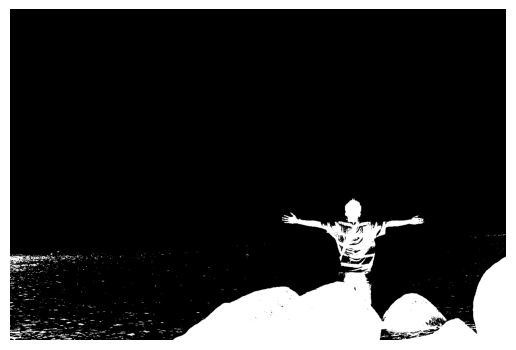

In [31]:
I1_kq1a = phanNguong(i1, 127, 0, 255, hamqd_a)
plt.imshow(I1_kq1a, cmap="gray")
plt.axis("off")
plt.show()

### 3. Một loại ảnh phổ biến được áp dụng phân ngưỡng là ảnh văn bản, với các vùng chữ là vùng đen (có giá trị mức xám thấp) và vùng nền và vùng trắng (có giá trị mức xám cao). Thử nghiệm thuật toán với một số ảnh văn bản đã tải sẵn ở bước chuẩn bị và một số ảnh tự chụp.



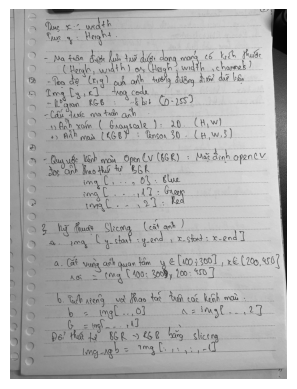

In [32]:
img = cv2.imread("doc.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap = "gray")
plt.axis("off")
plt.show()

In [33]:
def phanNguong(I, T, MIN, MAX):
    I_kq = np.copy(I)
    for i in range(I.shape[0]):
        for j in range(I.shape[1]):
            I_kq[i, j] = MAX if I[i, j] > T else MIN 

    return I_kq



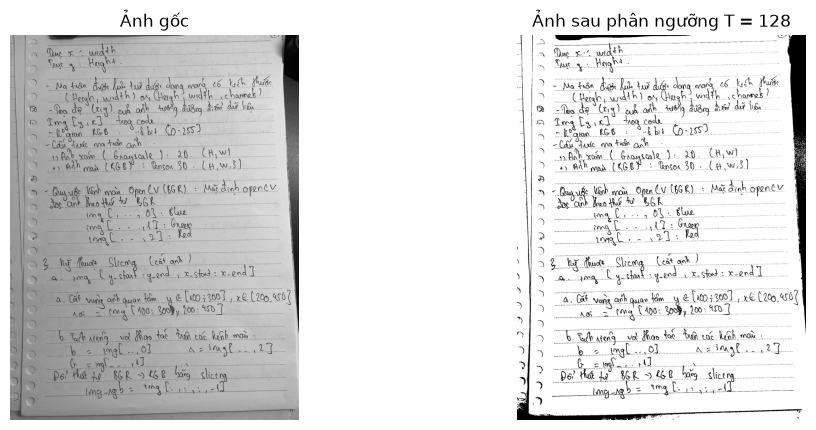

In [34]:
I_kq = phanNguong(img, 128, 0, 255)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(I_kq, cmap="gray")
plt.title("Ảnh sau phân ngưỡng T = 128")
plt.axis("off")

plt.show()

### 4. Mở rộng việc phân ngưỡng với ảnh màu bằng việc đồng thời phân ngưỡng trên 3 kênh màu.

Thực hành ví dụ với ảnh apple.jpg đã download trước. Cụ thể, phân ngưỡng với điều kiện: *139<R<245 và 82<G<149 và 17<B<82*

Đánh giá kết quả và thử nghiệm với ảnh tự chụp.

In [35]:
def phanNguongMau(I):
    I_kq = np.copy(I)

    for i in range(I.shape[0]):
        for j in range(I.shape[1]):
            R = I[i, j, 0]
            G = I[i, j, 1]
            B = I[i, j, 2]

            if R < 140 and 100 < G < 210 and 100 < B < 220:
                I_kq[i, j] = [255, 255, 255]
            else:
                I_kq[i, j] = [0, 0, 0]

    return I_kq

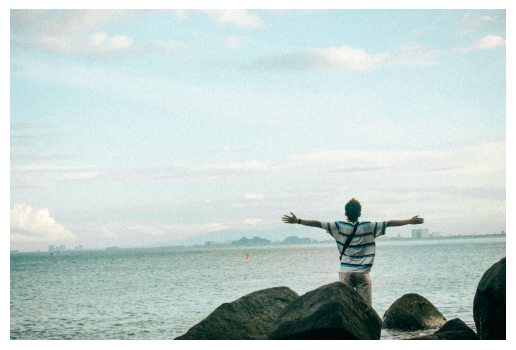

In [36]:
img = cv2.imread("ava.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis("off")
plt.show()

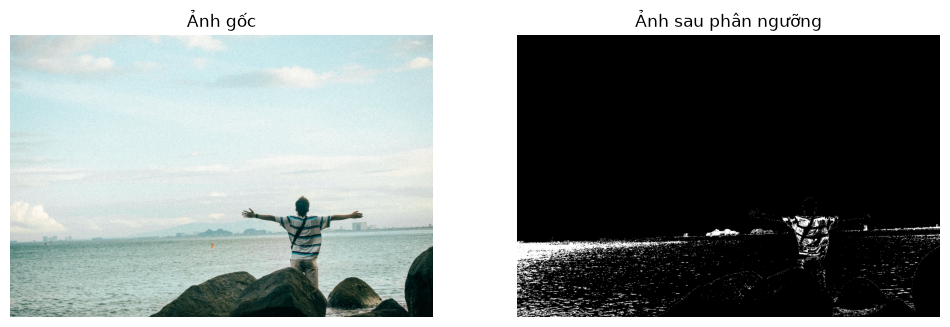

In [37]:
I_kq = phanNguongMau(img)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(I_kq)
plt.title("Ảnh sau phân ngưỡng")
plt.axis("off")

plt.show()

## Frame Differencing

1. Nguyên lý cơ bảnVideo về bản chất là một chuỗi các khung hình (frames) liên tiếp theo thời gian $t$. Khi camera cố định, vùng nền (background) sẽ ít thay đổi giữa các khung hình kề nhau, trong khi các đối tượng chuyển động sẽ làm giá trị pixel tại vị trí của chúng thay đổi đáng kể.Bằng cách tính hiệu số độ sáng (intensity difference) giữa hai hoặc nhiều khung hình liên tiếp, ta có thể dễ dàng tách biệt các vùng pixel có sự chuyển động.

``` 
"""
BTVN: Phát hiện chuyển động từ webcam (Frame Differencing)
 
Thuật toán:
1. Mở webcam
2. Lặp:
   - Đọc khung hình hiện tại -> I_cur
   - Tính D = |I_cur - I_prv|   (I_prv: ảnh trước đó)
   - Phân ngưỡng D -> hiển thị (T thường trong khoảng 5 - 30)
"""

```

In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

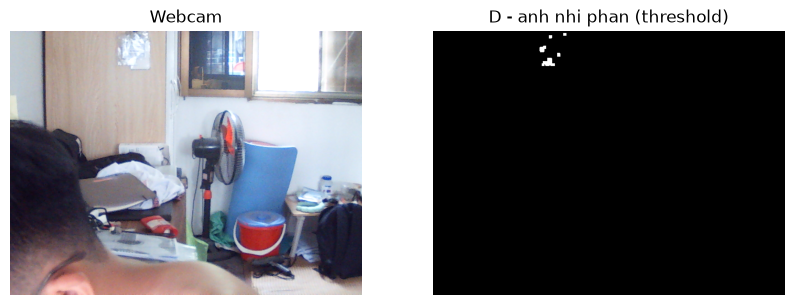

In [ ]:
# Threshold: filter gaul
T = 25
AREA_MIN = 500 

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Không mở được webcam!")
else:
    ret, frame = cap.read()
    I_prv = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    I_prv = cv2.GaussianBlur(I_prv, (5, 5), 0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            # Đọc khung hình hiện tại -> I_cur
            I_cur = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            I_cur = cv2.GaussianBlur(I_cur, (5, 5), 0)

            D = cv2.absdiff(I_cur, I_prv)

            # Phân ngưỡng D
            _, D_thresh = cv2.threshold(D, T, 255, cv2.THRESH_BINARY)
            D_thresh = cv2.dilate(D_thresh, None, iterations=2)

            # Vẽ khung chữ nhật quanh vùng chuyển động
            contours, _ = cv2.findContours(D_thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            frame_disp = frame.copy()
            for c in contours:
                if cv2.contourArea(c) < AREA_MIN:
                    continue
                x, y, w, h = cv2.boundingRect(c)
                cv2.rectangle(frame_disp, (x, y), (x + w, y + h), (0, 0, 255), 2)

            # Cập nhật I_prv cho vòng lặp sau
            I_prv = I_cur

            # ----- Hiển thị trong Jupyter -----
            clear_output(wait=True)
            axes[0].clear(); axes[1].clear()
            axes[0].imshow(cv2.cvtColor(frame_disp, cv2.COLOR_BGR2RGB))
            axes[0].set_title("Webcam")
            axes[0].axis("off")

            axes[1].imshow(D_thresh, cmap="gray")
            axes[1].set_title("D - anh nhi phan (threshold)")
            axes[1].axis("off")

            display(fig)

    except KeyboardInterrupt:
        print("Đã dừng.")
    finally:
        cap.release()
        plt.close(fig)